In [1]:
# Gneral Imports

import os
from pathlib import Path
import pickle
import pandas as pd
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt
import torch 
import torchvision
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
import cv2
import nibabel as nb


%matplotlib inline

In [26]:
base_folder = '/Users/SeanKelly1/Documents/FinalThesis(2023Ulster)/Raw/MR_nifti/T2w'
os.chdir(base_folder)
mri_t2 = os.listdir()
print(len(mri_t2)) # There are 4053 files in the folder



# Let's examine each file for uniform dimension
dim_0 = []
dim_1 = []
dim_2 = []
for temp in mri_t2:
    if temp == ".DS_Store":
        pass
    else:
        tensor_nifti = nb.load(temp) # The pics is extracted but remains in a nibabel object
        temp_arr = tensor_nifti.get_fdata() # Converts the nibabel object to numpy array
        lenght_slices = (temp_arr.shape)
        zeroth = lenght_slices[0]
        first = lenght_slices[1]
        second = lenght_slices[2]
        dim_0.append(zeroth)
        dim_1.append(first)
        dim_2.append(second)

print(set(dim_0))
print(set(dim_1))
print(set(dim_2))



# discard  on the second 128, 45, 60, 28, 127
    

4053
{256, 192, 96, 128, 228, 160, 232, 175, 176}
{256, 240, 96, 128}
{256, 128, 36, 38, 44, 45, 60, 26, 27, 28, 127}


(192, 256, 27)
sub-OAS30881_ses-d0152_acq-TSE_echo-2_T2w.nii.gz


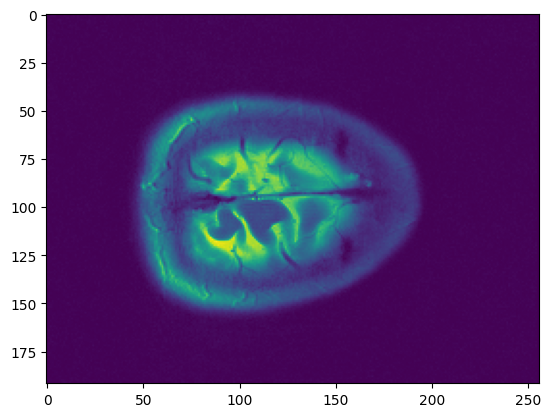

In [173]:
for temp in mri_t2:
    if temp == ".DS_Store":
        pass
    else:
        tensor_nifti = nb.load(temp) # The pics is extracted but remains in a nibabel object
        temp_arr = tensor_nifti.get_fdata() # Converts the nibabel object to numpy array
        lenght_slices = (temp_arr.shape)
        zeroth = lenght_slices[0]
        first = lenght_slices[1]
        second = lenght_slices[2]
        dim_0.append(zeroth)
        dim_1.append(first)
        dim_2.append(second)
        if second == 27:
            print(lenght_slices)
            plt.imshow(temp_arr[:, :, 25])
            print(temp)

            break

In [ ]:
256: 135 - 165
36: 17 - 26
38: 17 - 26
44: 27 - 35
26: 13 - 20
27: 13 - 20



In [187]:
processed_folder = "/Users/SeanKelly1/Documents/FinalThesis(2023Ulster)/Raw/All/MRI_T2"
adrc_folder = "/Users/SeanKelly1/Documents/FinalThesis(2023Ulster)/Spreadsheet/ADRC Clinical Data.csv"
os.chdir(base_folder)

base_folder = '/Users/SeanKelly1/Documents/FinalThesis(2023Ulster)/Raw/MR_nifti/T2w'
os.chdir(base_folder)
mri_t2 = os.listdir()
print(len(mri_t2)) # There are 4053 files in the folder




n = 0
cdr = 52
done_list = []
skipped_list = []
for t2 in mri_t2:
    temp_img = []

    if t2 == ".DS_Store" or t2 in done_list or t2 in skipped_list or cdr == None:
        pass
    else:
        try:
            # sub-OAS30003_ses-d2682_acq-AV45_pet.nii.gz
            subject_id = t2.split("-")[1].split("_")[0]
            assessement_id = t2.split("-")[2].split("_")[0]
            typ = t2.split("-")[-1].split("_")[0]
            raw_df = pd.read_csv(adrc_folder)
            cdr = max(raw_df[raw_df["Subject"] == subject_id]["cdr"])
            new_file_name = "{}_{}_{}".format(subject_id, typ, cdr)
            tensor_nifti = nb.load(t2) # The pics is extracted but remains in a nibabel object
            temp_arr = tensor_nifti.get_fdata() # Converts the nibabel object to numpy array
            lenght_slices = (temp_arr.shape)
            zeroth = lenght_slices[0]
            first = lenght_slices[1]
            second = lenght_slices[2]
            dim_0.append(zeroth)
            dim_1.append(first)
            dim_2.append(second)
            if second == 256:
                start = 135
                end = 165
            elif second == 36:
                start = 17
                end = 26
            elif second == 38:
                start = 17
                end = 26
            elif second == 44:
                start = 27
                end = 35
            elif second == 26:
                start = 13
                end = 20
            elif second == 27:
                start = 13
                end = 20
            for i in range(start, end):
                temp = temp_arr[:, :, i]
                new_file_name = "{}_{}_{}_{}".format(subject_id, typ, cdr, i)
                temp_folder = (processed_folder + "/" + str(cdr) + "/" + new_file_name + ".png")
                plt.imsave(temp_folder, temp)
                print("{} has been processed".format(t2))
                n += 1
            done_list.append(t2)
        except:
            print(f"could not process {t2}" )
            skipped_list.append(t2)
    
                
print("{} images saved and classified by cdr".format(n))

print(len(skipped_list))


print(len(done_list))

# 256: 135 - 165
# 36: 17 - 26
# 38: 17 - 26
# 44: 27 - 35
# 26: 13 - 20
# 27: 13 - 20

4053
sub-OAS31125_ses-d0735_acq-TSE_T2w.nii.gz has been processed
sub-OAS31125_ses-d0735_acq-TSE_T2w.nii.gz has been processed
sub-OAS31125_ses-d0735_acq-TSE_T2w.nii.gz has been processed
sub-OAS31125_ses-d0735_acq-TSE_T2w.nii.gz has been processed
sub-OAS31125_ses-d0735_acq-TSE_T2w.nii.gz has been processed
sub-OAS31125_ses-d0735_acq-TSE_T2w.nii.gz has been processed
sub-OAS31125_ses-d0735_acq-TSE_T2w.nii.gz has been processed
sub-OAS31125_ses-d0735_acq-TSE_T2w.nii.gz has been processed
sub-OAS31125_ses-d0735_acq-TSE_T2w.nii.gz has been processed
sub-OAS31001_ses-d3394_acq-TSE_T2w.nii.gz has been processed
sub-OAS31001_ses-d3394_acq-TSE_T2w.nii.gz has been processed
sub-OAS31001_ses-d3394_acq-TSE_T2w.nii.gz has been processed
sub-OAS31001_ses-d3394_acq-TSE_T2w.nii.gz has been processed
sub-OAS31001_ses-d3394_acq-TSE_T2w.nii.gz has been processed
sub-OAS31001_ses-d3394_acq-TSE_T2w.nii.gz has been processed
sub-OAS31001_ses-d3394_acq-TSE_T2w.nii.gz has been processed
sub-OAS31001_ses-d3

In [195]:
import pathlib


dir = pathlib.Path(processed_folder)

image_count = len(list(dir.glob('3.0/*.png')))
print(image_count)

467
